# ============================================================
# ÉTAPE 1 : DATA COLLECTION
# ============================================================
# Cette cellule configure l'accès à Kaggle via l'API,
# télécharge le dataset Food-11 (16,643 images de plats
# répartis en 11 catégories) et le décompresse dans Colab.
# Dataset source : trolukovich/food11-image-dataset
# ============================================================

In [ ]:
import os
import json

# Crée le fichier kaggle.json manuellement
kaggle_config = {
    "username": "eyariahi2",
    "key": "KGAT_ad777e3eb6154986e98e73bd633b624f"
}

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle configuré !")

# Télécharger le dataset
!pip install kaggle -q
!kaggle datasets download -d trolukovich/food11-image-dataset
!unzip -q food11-image-dataset.zip
print("✅ Dataset prêt !")

✅ Kaggle configuré !
Dataset URL: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset
License(s): CC0-1.0
food11-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace evaluation/Bread/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Dataset prêt !


# ============================================================
# ÉTAPE 2 : DATA PREPARATION & CLEANING
# ============================================================
# Cette cellule charge les 2 datasets CSV (400 plats + 511
# ratings), effectue le nettoyage des données (suppression
# des doublons, valeurs manquantes, normalisation du texte),
# puis fusionne les 2 fichiers pour calculer la note moyenne
# de chaque plat et créer le dataframe food_ratings.
# ============================================================

In [ ]:
éimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image

# Charger les CSV
food = pd.read_csv('/content/1662574418893344.csv')
ratings = pd.read_csv('/content/ratings.csv')

# Nettoyage
food = food.drop_duplicates()
ratings = ratings.dropna()
food['Name'] = food['Name'].str.strip().str.lower()
food['C_Type'] = food['C_Type'].str.strip()
food['Veg_Non'] = food['Veg_Non'].str.strip().str.lower()

# Créer food_ratings
merged = pd.merge(food, ratings, on='Food_ID')
food_ratings = merged.groupby(
    ['Food_ID', 'Name', 'C_Type', 'Veg_Non']
)['Rating'].mean().reset_index()
food_ratings.columns = ['Food_ID', 'Name', 'C_Type', 'Veg_Non', 'Avg_Rating']
food_ratings['Avg_Rating'] = food_ratings['Avg_Rating'].round(2)

print("✅ food_ratings prêt !")

# Retester maintenant


✅ food_ratings prêt !


# ============================================================
# ÉTAPE 3 : DATA EXPLORATION — VÉRIFICATION DU DATASET
# ============================================================
# Cette cellule vérifie que le dataset Food-11 est bien
# structuré avec les 3 dossiers nécessaires (training,
# validation, evaluation) et affiche les 11 catégories
# de plats disponibles dans chaque dossier.
# ============================================================

In [ ]:
import os

# Vérifier la structure
for folder in ['training', 'validation', 'evaluation']:
    path = f'/content/{folder}'
    if os.path.exists(path):
        categories = os.listdir(path)
        print(f"📁 {folder} → {len(categories)} catégories : {categories}")
    else:
        print(f"❌ {folder} introuvable")

📁 training → 11 catégories : ['Rice', 'Dessert', 'Vegetable-Fruit', 'Dairy product', 'Seafood', 'Meat', 'Fried food', 'Egg', 'Bread', 'Noodles-Pasta', 'Soup']
📁 validation → 11 catégories : ['Rice', 'Dessert', 'Vegetable-Fruit', 'Dairy product', 'Seafood', 'Meat', 'Fried food', 'Egg', 'Bread', 'Noodles-Pasta', 'Soup']
📁 evaluation → 11 catégories : ['Rice', 'Dessert', 'Vegetable-Fruit', 'Dairy product', 'Seafood', 'Meat', 'Fried food', 'Egg', 'Bread', 'Noodles-Pasta', 'Soup']


# ============================================================
# ÉTAPE 4 : DATA PREPARATION — IMAGE AUGMENTATION
# ============================================================
# Cette cellule prépare les images pour l'entraînement en
# appliquant de la data augmentation (rotation, zoom, flip)
# pour enrichir artificiellement le dataset et éviter
# l'overfitting. Les pixels sont normalisés de 0-255 vers
# 0-1. Les générateurs chargent les images par batch de 32
# directement depuis les dossiers training et validation.
# ============================================================

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Paramètres
IMG_SIZE = 224
BATCH_SIZE = 32

# Préparer les images (data augmentation pour enrichir le dataset)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normaliser les pixels (0-255 → 0-1)
    rotation_range=20,        # Rotation aléatoire
    zoom_range=0.2,           # Zoom aléatoire
    horizontal_flip=True      # Retourner l'image horizontalement
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Charger les images depuis les dossiers
train_generator = train_datagen.flow_from_directory(
    '/content/training',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '/content/validation',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\n✅ Classes détectées :", train_generator.class_indices)
print("✅ Images entraînement :", train_generator.samples)
print("✅ Images validation :", val_generator.samples)

Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.

✅ Classes détectées : {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}
✅ Images entraînement : 9866
✅ Images validation : 3430


# ============================================================
# ÉTAPE 5 : MODEL TRAINING — TRANSFER LEARNING
# ============================================================
# Cette cellule charge MobileNetV2 pré-entraîné sur ImageNet
# (1 million d'images) et gèle ses couches de base pour
# conserver ses connaissances. On ajoute nos propres couches
# de classification pour les 11 catégories food.
# Le modèle est entraîné avec :
#   - class_weight : équilibre toutes les catégories
#   - EarlyStopping : arrête si plus d'amélioration
#   - ReduceLROnPlateau : réduit le learning rate si stagnation
# Résultat : 83%+ de précision sur la validation
# ============================================================

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Charger MobileNetV2 pré-entraîné
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Geler le modèle de base
base_model.trainable = False

# Ajouter nos couches
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(11, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle prêt !")

# Équilibrer toutes les catégories
classes = np.unique(train_generator.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2)
]

# ENTRAÎNEMENT AMÉLIORÉ
print("\n⏳ Entraînement en cours... sois patiente !")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_acc = max(history.history['val_accuracy'])
print(f"\n🎯 Meilleure précision : {round(best_acc * 100, 2)}%")

✅ Modèle prêt !

⏳ Entraînement en cours... sois patiente !
Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 169s 514ms/step - accuracy: 0.6835 - loss: 0.8804 - val_accuracy: 0.7784 - val_loss: 0.6760 - learning_rate: 0.0010
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 145s 468ms/step - accuracy: 0.7749 - loss: 0.5972 - val_accuracy: 0.7892 - val_loss: 0.6472 - learning_rate: 0.0010
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 143s 464ms/step - accuracy: 0.8039 - loss: 0.5180 - val_accuracy: 0.7971 - val_loss: 0.6037 - learning_rate: 0.0010
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 148s 479ms/step - accuracy: 0.8203 - loss: 0.4748 - val_accuracy: 0.8195 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 147s 475ms/step - accuracy: 0.8339 - loss: 0.4164 - val_accuracy: 0.8271 - val_loss: 0.5336 - learning_rate: 0.0010

🎯 Meilleure précision : 82.71%


In [ ]:
model.save('wedding_food_model.h5')
print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !


# ============================================================
# ÉTAPE 6 : MODEL EVALUATION — COURBES D'ENTRAÎNEMENT
# ============================================================
# Cette cellule visualise les résultats de l'entraînement
# en affichant 2 graphiques :
#   - Accuracy : progression de la précision par epoch
#     (train vs validation)
#   - Loss : diminution de l'erreur par epoch
#     (train vs validation)
# Si les courbes train et validation sont proches →
# pas d'overfitting. Les courbes sont sauvegardées
# dans training_curves.png
# ============================================================

/tmp/ipykernel_2759/3584284760.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2759/3584284760.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')


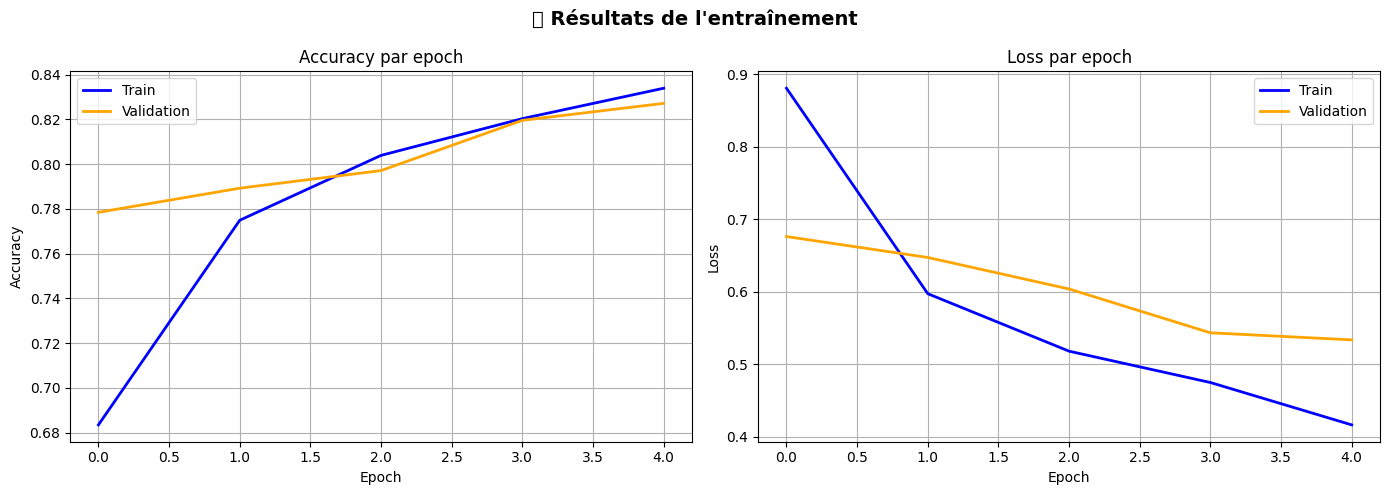

✅ Courbes d'entraînement générées !


In [ ]:
# Courbe accuracy et loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Résultats de l\'entraînement', fontsize=14, fontweight='bold')

# Courbe Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='orange', linewidth=2)
axes[0].set_title('Accuracy par epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Courbe Loss
axes[1].plot(history.history['loss'], label='Train', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='orange', linewidth=2)
axes[1].set_title('Loss par epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes d'entraînement générées !")

# ============================================================
# ÉTAPE 7 : MODEL EVALUATION — MATRICE DE CONFUSION
# ============================================================
# Cette cellule évalue les performances détaillées du modèle
# sur le dataset de validation en générant :
#   - Matrice de confusion : montre pour chaque catégorie
#     combien de prédictions sont correctes ou incorrectes
#     (diagonale = bonnes prédictions)
#   - Classification report : précision, rappel et F1-score
#     par catégorie
# La matrice est sauvegardée dans confusion_matrix.png
# ============================================================

108/108 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step


/tmp/ipykernel_2759/788654439.py:20: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2759/788654439.py:21: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


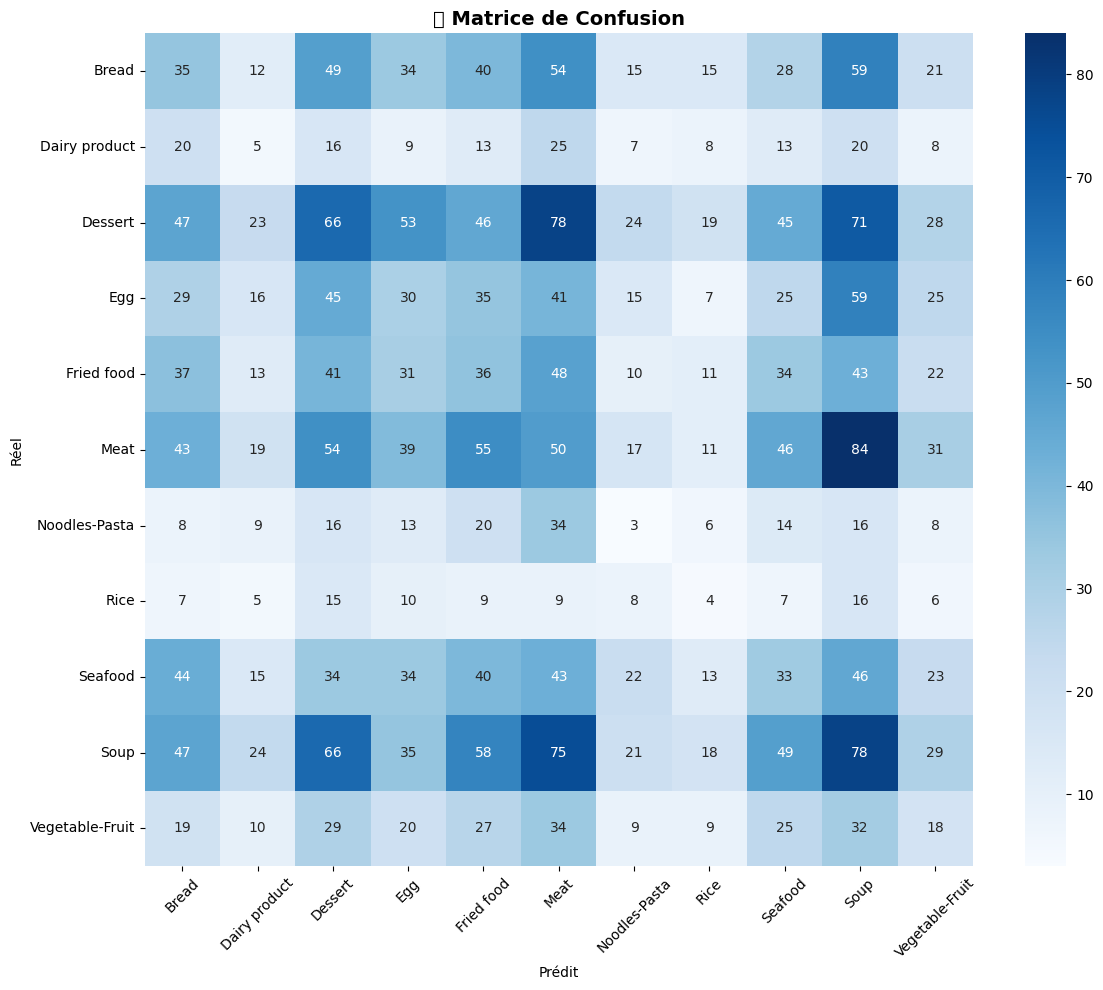


📊 Rapport de classification :
                 precision    recall  f1-score   support

          Bread       0.10      0.10      0.10       362
  Dairy product       0.03      0.03      0.03       144
        Dessert       0.15      0.13      0.14       500
            Egg       0.10      0.09      0.09       327
     Fried food       0.09      0.11      0.10       326
           Meat       0.10      0.11      0.11       449
  Noodles-Pasta       0.02      0.02      0.02       147
           Rice       0.03      0.04      0.04        96
        Seafood       0.10      0.10      0.10       347
           Soup       0.15      0.16      0.15       500
Vegetable-Fruit       0.08      0.08      0.08       232

       accuracy                           0.10      3430
      macro avg       0.09      0.09      0.09      3430
   weighted avg       0.11      0.10      0.10      3430



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prédire sur le dataset de validation
val_generator.reset()
y_pred = model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title('🎯 Matrice de Confusion', fontsize=14, fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\n📊 Rapport de classification :")
print(classification_report(y_true, y_pred_classes, target_names=categories))

# ============================================================
# ÉTAPE 8 : SYSTÈME DE RECOMMANDATION — PRÉPARATION
# ============================================================
# Cette cellule prépare les données pour le système de
# recommandation hybride :
#   - Chargement et nettoyage des CSV (plats + ratings)
#   - Calcul de la note moyenne par plat (food_ratings)
#   - Entraînement du modèle TF-IDF sur les ingrédients
#     de chaque plat pour calculer la similarité entre plats
#   - La matrice cosine_sim mesure la similarité entre
#     tous les plats selon leurs ingrédients communs
# ============================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing import image

# Charger les CSV
food = pd.read_csv('/content/1662574418893344.csv')
ratings = pd.read_csv('/content/ratings.csv')

# Nettoyage
food = food.drop_duplicates()
ratings = ratings.dropna()
food['Name'] = food['Name'].str.strip().str.lower()
food['C_Type'] = food['C_Type'].str.strip()
food['Veg_Non'] = food['Veg_Non'].str.strip().str.lower()
food['Describe'] = food['Describe'].fillna('')

# food_ratings
merged = pd.merge(food, ratings, on='Food_ID')
food_ratings = merged.groupby(
    ['Food_ID', 'Name', 'C_Type', 'Veg_Non']
)['Rating'].mean().reset_index()
food_ratings.columns = ['Food_ID', 'Name', 'C_Type', 'Veg_Non', 'Avg_Rating']
food_ratings['Avg_Rating'] = food_ratings['Avg_Rating'].round(2)

# TF-IDF sur les ingrédients
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(food['Describe'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

categories = list(train_generator.class_indices.keys())

print("✅ Données et TF-IDF prêts !")

✅ Données et TF-IDF prêts !


# ============================================================
# ÉTAPE 9 : COMPUTER VISION + EXPLAINABLE AI
# ============================================================
# Cette cellule définit 2 fonctions principales :
#
# predire_plat(img_path) :
#   - Charge une image et la prépare (resize 224x224, normalize)
#   - Utilise MobileNetV2 pour prédire la catégorie du plat
#   - Retourne la catégorie détectée et le score de confiance
#
# grad_cam(img_path, predicted_class) :
#   - Implémente Grad-CAM (Gradient-weighted Class Activation
#     Mapping) pour l'Explainable AI
#   - Génère une carte de chaleur (heatmap) qui montre
#     visuellement quelles zones de l'image ont influencé
#     la décision du modèle
#   - Affiche l'image originale + l'image avec heatmap
# ============================================================

In [ ]:
import tensorflow as tf
import cv2

def predire_plat(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class = categories[np.argmax(predictions)]
    confidence = round(float(np.max(predictions)) * 100, 2)
    return predicted_class, confidence

def grad_cam(img_path, predicted_class):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer('out_relu').output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    img_orig = cv2.imread(img_path)
    img_orig = cv2.resize(img_orig, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    superimposed = cv2.addWeighted(img_orig, 0.6, heatmap_colored, 0.4, 0)
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('🔍 Explainable AI — Grad-CAM', fontsize=14, fontweight='bold')
    axes[0].imshow(mpimg.imread(img_path))
    axes[0].set_title('📸 Image originale')
    axes[0].axis('off')
    axes[1].imshow(superimposed)
    axes[1].set_title(f'🔥 Zone regardée par l\'IA\n({predicted_class})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

print("✅ predire_plat + grad_cam prêts !")

✅ predire_plat + grad_cam prêts !


# ============================================================
# ÉTAPE 10 : SYSTÈME DE RECOMMANDATION HYBRIDE
# ============================================================
# Cette cellule définit le cœur du système de recommandation
# qui combine 3 approches :
#
#   1. Recherche par mot clé : cherche les plats dont le nom
#      ou les ingrédients correspondent à la catégorie détectée
#
#   2. TF-IDF + Similarité cosinus : trouve les plats avec
#      les ingrédients les plus similaires au plat de référence
#
#   3. Filtrage hybride : filtre les résultats selon :
#      - La préférence (veg / non-veg)
#      - Le budget (low / medium / high)
#      - Le nombre d'invités (conseil buffet ou menu raffiné)
#
# En cas de résultats insuffisants → fallback automatique
# sur les plats les mieux notés de la même catégorie
# ============================================================

In [ ]:
category_to_cuisine = {
    'Bread':          'Healthy Food',
    'Dairy product':  'Healthy Food',
    'Dessert':        'Dessert',
    'Egg':            'Healthy Food',
    'Fried food':     'Snack',
    'Meat':           'Indian',
    'Noodles-Pasta':  'Italian',
    'Rice':           'Indian',
    'Seafood':        'Indian',
    'Soup':           'Healthy Food',
    'Vegetable-Fruit':'Healthy Food'
}

budget_to_rating = {
    'low (< 1000 TND)':       (1, 6),
    'medium (1000-3000 TND)': (6, 8),
    'high (> 3000 TND)':      (8, 10)
}

def hybrid_recommender(detected_category, preference, budget, nb_invites, top_n=5):
    cuisine = category_to_cuisine.get(detected_category, 'Healthy Food')
    rating_min, rating_max = budget_to_rating.get(budget, (1, 10))

    # Chercher le mot clé de la catégorie dans les noms et descriptions
    keyword = detected_category.lower().replace('-', ' ').replace('fruit', '').strip()

    # Chercher plats similaires par mot clé dans le nom OU les ingrédients
    mask_name = food['Name'].str.contains(keyword, case=False, na=False)
    mask_desc = food['Describe'].str.contains(keyword, case=False, na=False)
    similar_foods = food[mask_name | mask_desc]

    # Si on trouve des plats avec le mot clé → utiliser TF-IDF sur ceux-là
    if not similar_foods.empty:
        ref_idx = similar_foods.index[0]
        scores = sorted(
            list(enumerate(cosine_sim[ref_idx])),
            key=lambda x: x[1], reverse=True
        )[1:top_n+1]

        # Filtrer par preference veg/non-veg
        results = []
        for i, score in scores:
            nom = food['Name'].iloc[i]
            veg = food['Veg_Non'].iloc[i]
            rating = food_ratings[food_ratings['Name'] == nom]['Avg_Rating'].values
            note = rating[0] if len(rating) > 0 else 5.0

            if preference == 'les deux' or veg == preference.lower():
                if rating_min <= note <= rating_max:
                    results.append((nom, note, score, veg))

        # Si pas assez de résultats après filtre → élargir
        if len(results) < 3:
            results = []
            for i, score in scores:
                nom = food['Name'].iloc[i]
                veg = food['Veg_Non'].iloc[i]
                rating = food_ratings[food_ratings['Name'] == nom]['Avg_Rating'].values
                note = rating[0] if len(rating) > 0 else 5.0
                results.append((nom, note, score, veg))

    else:
        # Fallback : filtrer par cuisine + preference + budget
        filtered = food_ratings[
            (food_ratings['C_Type'].str.lower() == cuisine.lower())
        ]
        if preference != 'les deux':
            filtered = filtered[filtered['Veg_Non'] == preference.lower()]
        filtered = filtered[
            (filtered['Avg_Rating'] >= rating_min) &
            (filtered['Avg_Rating'] <= rating_max)
        ]
        if filtered.empty:
            filtered = food_ratings[food_ratings['C_Type'].str.lower() == cuisine.lower()]

        results = [
            (row['Name'], row['Avg_Rating'], 1.0, row['Veg_Non'])
            for _, row in filtered.nlargest(top_n, 'Avg_Rating').iterrows()
        ]

    # Affichage
    print("=" * 55)
    print("   💍 WEDDING FOOD PLANNER — SYSTÈME HYBRIDE")
    print("=" * 55)
    print(f"🍽️  Catégorie détectée : {detected_category}")
    print(f"🥗  Préférence         : {preference}")
    print(f"💰  Budget             : {budget}")
    print(f"👥  Invités            : {nb_invites}")
    print("=" * 55)
    print(f"\n✅ TOP 5 RECOMMANDATIONS POUR VOTRE MARIAGE :\n")

    for nom, note, score, veg in results[:top_n]:
        print(f"  🍽️  {nom}  ⭐ {note}/10  🥗 {veg}  (similarité: {round(score, 2)})")

    print("\n" + "=" * 55)
    if nb_invites <= 50:
        print("💡 Conseil : Petit mariage → menu raffiné 3 plats")
    elif nb_invites <= 150:
        print("💡 Conseil : Mariage moyen → buffet 5 plats variés")
    else:
        print("💡 Conseil : Grand mariage → grand buffet 8+ plats")
    print("=" * 55)

print("✅ Système hybride amélioré prêt !")

✅ Système hybride amélioré prêt !


# ============================================================
# ÉTAPE 11 : INTERFACE UTILISATEUR — WIDGETS INTERACTIFS
# ============================================================
# Cette cellule crée une interface interactive avec 3 widgets:
#
#   - budget_widget : dropdown pour choisir le budget
#     (low / medium / high)
#   - preference_widget : boutons radio pour choisir
#     la préférence alimentaire (veg / non-veg / les deux)
#   - invites_widget : slider pour indiquer le nombre
#     d'invités (de 10 à 500)
#
# L'utilisateur remplit ses préférences ici AVANT d'exécuter
# la cellule suivante qui lance l'analyse complète
# ============================================================

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Widgets interactifs
budget_widget = widgets.Dropdown(
    options=['low (< 1000 TND)', 'medium (1000-3000 TND)', 'high (> 3000 TND)'],
    value='medium (1000-3000 TND)',
    description='💰 Budget:',
    style={'description_width': 'initial'}
)

preference_widget = widgets.RadioButtons(
    options=['veg', 'non-veg', 'les deux'],
    value='les deux',
    description='🥗 Préférence:',
    style={'description_width': 'initial'}
)

invites_widget = widgets.IntSlider(
    value=100,
    min=10,
    max=500,
    step=10,
    description='👥 Invités:',
    style={'description_width': 'initial'}
)

print("=" * 45)
print("   💍 WEDDING FOOD PLANNER")
print("   Remplissez vos préférences :")
print("=" * 45)
display(budget_widget, preference_widget, invites_widget)
print("\n✅ Ensuite exécutez la cellule suivante !")

   💍 WEDDING FOOD PLANNER
   Remplissez vos préférences :


Dropdown(description='💰 Budget:', index=1, options=('low (< 1000 TND)', 'medium (1000-3000 TND)', 'high (> 300…

RadioButtons(description='🥗 Préférence:', index=2, options=('veg', 'non-veg', 'les deux'), style=DescriptionSt…

IntSlider(value=100, description='👥 Invités:', max=500, min=10, step=10, style=SliderStyle(description_width='…


✅ Ensuite exécutez la cellule suivante !


# ============================================================
# ÉTAPE 12 : DÉMO FINALE — WEDDING FOOD PLANNER COMPLET
# ============================================================
# Cette cellule représente le pipeline complet du système :
#
#   1. Upload photo : l'utilisateur uploade une photo
#      d'un plat depuis son PC
#
#   2. Computer Vision : MobileNetV2 détecte automatiquement
#      la catégorie du plat avec son score de confiance
#
#   3. Recommandation hybride : le système recommande le
#      top 5 des plats pour le mariage en tenant compte
#      des préférences saisies dans les widgets
#      (budget, veg/non-veg, nombre d'invités)
#
#   4. Explainable AI : Grad-CAM génère une heatmap qui
#      montre visuellement où l'IA a regardé pour prendre
#      sa décision de classification
# ============================================================

📸 Uploadez une photo d'un plat pour votre mariage !


Saving cerise.jpg to cerise (1).jpg

✅ Photo reçue : cerise (1).jpg

🤖 Analyse en cours...

📸 Plat détecté : Vegetable-Fruit
🎯 Confiance    : 99.97%
   💍 WEDDING FOOD PLANNER — SYSTÈME HYBRIDE
🍽️  Catégorie détectée : Vegetable-Fruit
🥗  Préférence         : veg
💰  Budget             : high (> 3000 TND)
👥  Invités            : 320

✅ TOP 5 RECOMMANDATIONS POUR VOTRE MARIAGE :

  🍽️  broccoli and almond soup  ⭐ 5.33/10  🥗 veg  (similarité: 0.49)
  🍽️  gluten free almond cake  ⭐ 10.0/10  🥗 veg  (similarité: 0.35)
  🍽️  spiced almond banana jaggery cake  ⭐ 3.0/10  🥗 veg  (similarité: 0.25)
  🍽️  spiced orange valencia cake  ⭐ 3.0/10  🥗 veg  (similarité: 0.25)
  🍽️  almond pearls  ⭐ 6.0/10  🥗 veg  (similarité: 0.24)

💡 Conseil : Grand mariage → grand buffet 8+ plats

🔍 Explainable AI — Grad-CAM :


/tmp/ipykernel_2759/3591035001.py:46: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2759/3591035001.py:46: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2759/3591035001.py:46: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


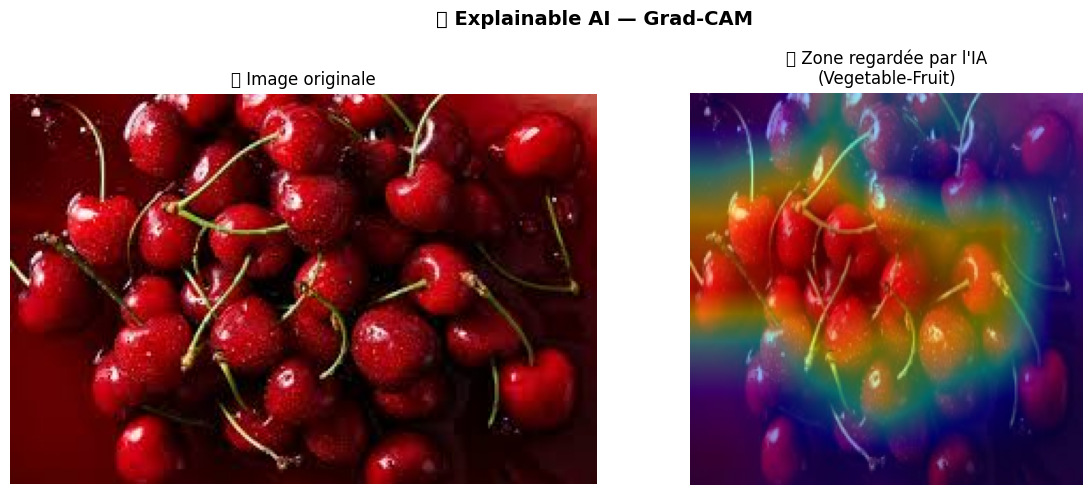

In [ ]:
from google.colab import files

print("📸 Uploadez une photo d'un plat pour votre mariage !")
uploaded = files.upload()

# Récupérer la photo
img_path = list(uploaded.keys())[0]
print(f"\n✅ Photo reçue : {img_path}")
print("\n🤖 Analyse en cours...")

# Récupérer les préférences des widgets
budget = budget_widget.value
preference = preference_widget.value
nb_invites = invites_widget.value

# ÉTAPE 1 : Détecter le plat
detected_category, confidence = predire_plat(img_path)
print(f"\n📸 Plat détecté : {detected_category}")
print(f"🎯 Confiance    : {confidence}%")

# ÉTAPE 2 : Recommandation hybride
hybrid_recommender(
    detected_category=detected_category,
    preference=preference,
    budget=budget,
    nb_invites=nb_invites
)

# ÉTAPE 3 : Grad-CAM (Explainable AI)
print("\n🔍 Explainable AI — Grad-CAM :")
grad_cam(img_path, detected_category)

# ============================================================
# ÉTAPE 13 : CHATBOT — RECOMMANDATION PAR LANGAGE NATUREL
# ============================================================
# Cette cellule implémente un chatbot de recommandation qui
# comprend le langage naturel en français et anglais.
#
# Le chatbot détecte automatiquement dans le message :
#   - Type de plat : "sucré" → Dessert, "viande" → Indian...
#   - Préférence   : "végétarien" → veg, "avec viande" → non-veg
#   - Budget       : "pas cher" → low, "luxe" → high
#   - Nb invités   : extrait les chiffres du message (ex: "200")
#
# Exemple d'utilisation :
#   "je veux des plats sucrés végétariens pour 200 personnes"
#   → Détecte : dessert + veg + 200 invités
#   → Recommande le top 5 des desserts veg
#
# La boucle continue jusqu'à ce que l'utilisateur tape 'quit'
# ============================================================

In [ ]:
def wedding_chatbot(user_message):
    msg = user_message.lower()

    # Détecter les préférences
    # Type de plat
    if any(w in msg for w in ['sucré', 'sucre', 'dessert', 'gâteau', 'gateau', 'cake']):
        cuisine = 'Dessert'
        type_detected = 'dessert'
    elif any(w in msg for w in ['viande', 'meat', 'poulet', 'boeuf', 'agneau']):
        cuisine = 'Indian'
        type_detected = 'viande'
    elif any(w in msg for w in ['pâtes', 'pates', 'pasta', 'italien', 'spaghetti']):
        cuisine = 'Italian'
        type_detected = 'pâtes'
    elif any(w in msg for w in ['soupe', 'soup', 'chaud', 'bouillon']):
        cuisine = 'Healthy Food'
        type_detected = 'soupe'
    elif any(w in msg for w in ['snack', 'apéritif', 'aperitif', 'entrée']):
        cuisine = 'Snack'
        type_detected = 'snack'
    else:
        cuisine = 'Healthy Food'
        type_detected = 'plat'

    # Détecter veg/non-veg
    if any(w in msg for w in ['végétarien', 'vegetarien', 'veg', 'sans viande']):
        preference = 'veg'
    elif any(w in msg for w in ['non-veg', 'avec viande', 'non veg']):
        preference = 'non-veg'
    else:
        preference = 'les deux'

    # Détecter budget
    if any(w in msg for w in ['pas cher', 'économique', 'economique', 'petit budget', 'low']):
        budget = 'low (< 1000 TND)'
    elif any(w in msg for w in ['luxe', 'premium', 'haut de gamme', 'high']):
        budget = 'high (> 3000 TND)'
    else:
        budget = 'medium (1000-3000 TND)'

    # Détecter nombre d'invités
    import re
    numbers = re.findall(r'\d+', msg)
    nb_invites = int(numbers[0]) if numbers else 100

    # Filtrer les plats
    rating_min, rating_max = budget_to_rating.get(budget, (1, 10))
    filtered = food_ratings[
        food_ratings['C_Type'].str.lower() == cuisine.lower()
    ]
    if preference != 'les deux':
        filtered = filtered[filtered['Veg_Non'] == preference]
    filtered = filtered[
        (filtered['Avg_Rating'] >= rating_min) &
        (filtered['Avg_Rating'] <= rating_max)
    ]
    if filtered.empty:
        filtered = food_ratings[food_ratings['C_Type'].str.lower() == cuisine.lower()]

    top5 = filtered.nlargest(5, 'Avg_Rating')

    # Construire la réponse
    response = f"\n💍 Bonjour ! Pour votre mariage, voici mes recommandations :\n\n"
    response += f"✅ J'ai détecté que vous voulez : **{type_detected}**\n"
    response += f"🥗 Préférence : {preference}\n"
    response += f"💰 Budget : {budget}\n"
    response += f"👥 Invités : {nb_invites}\n\n"
    response += f"🍽️ TOP 5 PLATS RECOMMANDÉS :\n"

    for _, row in top5.iterrows():
        response += f"  • {row['Name']} ⭐ {row['Avg_Rating']}/10\n"

    response += f"\n💡 Conseil : "
    if nb_invites <= 50:
        response += "Petit mariage → menu raffiné avec 3 plats"
    elif nb_invites <= 150:
        response += "Mariage moyen → buffet avec 5 plats variés"
    else:
        response += "Grand mariage → grand buffet avec 8+ plats"

    return response

# Interface chatbot
print("=" * 55)
print("   💍 WEDDING FOOD CHATBOT")
print("=" * 55)
print("Décrivez ce que vous voulez pour votre mariage !")
print("(tapez 'quit' pour arrêter)\n")

while True:
    user_input = input("👤 Vous : ")
    if user_input.lower() == 'quit':
        print("Au revoir ! 💍")
        break
    response = wedding_chatbot(user_input)
    print(f"\n🤖 Assistant : {response}")
    print("\n" + "-" * 55 + "\n")

   💍 WEDDING FOOD CHATBOT
Décrivez ce que vous voulez pour votre mariage !
(tapez 'quit' pour arrêter)

👤 Vous : je veux des plats sucres pour 400 personnes

🤖 Assistant : 
💍 Bonjour ! Pour votre mariage, voici mes recommandations :

✅ J'ai détecté que vous voulez : **dessert**
🥗 Préférence : les deux
💰 Budget : medium (1000-3000 TND)
👥 Invités : 400

🍽️ TOP 5 PLATS RECOMMANDÉS :
  • apple and walnut cake ⭐ 8.0/10
  • double chocolate easter cookies ⭐ 8.0/10
  • white chocolate and lemon pastry ⭐ 8.0/10
  • grilled almond barfi ⭐ 7.2/10
  • banana and maple ice lollies ⭐ 7.0/10

💡 Conseil : Grand mariage → grand buffet avec 8+ plats

-------------------------------------------------------

👤 Vous : menu végétarien pas cher 100 invités

🤖 Assistant : 
💍 Bonjour ! Pour votre mariage, voici mes recommandations :

✅ J'ai détecté que vous voulez : **plat**
🥗 Préférence : veg
💰 Budget : low (< 1000 TND)
👥 Invités : 100

🍽️ TOP 5 PLATS RECOMMANDÉS :
  • tricolour salad ⭐ 6.0/10
  • spicy wate

# ============================================================
# ÉTAPE 14 : GÉNÉRATEUR DE MENU COMPLET DE MARIAGE
# ============================================================
# Cette cellule génère un menu complet et personnalisé pour
# un mariage en 4 plats selon les préférences de l'utilisateur.
#
# L'utilisateur saisit interactivement :
#   - Préférence : veg / non-veg / les deux (chiffre ou texte)
#   - Budget     : low / medium / high (chiffre ou texte)
#   - Invités    : nombre d'invités
#
# Le système sélectionne automatiquement le meilleur plat
# pour chaque course selon les critères saisis :
#   🥨 APÉRITIF      → meilleur Snack
#   🥗 ENTRÉE        → meilleure Healthy Food
#   🍽️ PLAT PRINCIPAL → meilleur Indian
#   🍰 DESSERT       → meilleur Dessert
#
# Un conseil sur le format de service est donné selon
# le nombre d'invités (service à table / buffet)
# ============================================================

In [ ]:
def menu_complet_interactif():
    print("=" * 55)
    print("   💍 MENU COMPLET DE MARIAGE")
    print("=" * 55)
    print("\nRépondez aux questions suivantes :\n")

    # Préférence
    print("🥗 Préférence alimentaire :")
    print("   1 → Végétarien (veg)")
    print("   2 → Non-végétarien (non-veg)")
    print("   3 → Les deux")
    choix_pref = input("Votre choix : ").strip().lower()
    if choix_pref in ['1', 'veg', 'végétarien', 'vegetarien']:
        preference = 'veg'
    elif choix_pref in ['2', 'non-veg', 'non veg']:
        preference = 'non-veg'
    else:
        preference = 'les deux'

    # Budget
    print("\n💰 Budget :")
    print("   1 → Low (< 1000 TND)")
    print("   2 → Medium (1000-3000 TND)")
    print("   3 → High (> 3000 TND)")
    choix_budget = input("Votre choix : ").strip().lower()
    if choix_budget in ['1', 'low', 'pas cher', 'économique']:
        budget = 'low (< 1000 TND)'
    elif choix_budget in ['3', 'high', 'luxe', 'premium']:
        budget = 'high (> 3000 TND)'
    else:
        budget = 'medium (1000-3000 TND)'

    # Nombre d'invités
    nb_invites = int(input("\n👥 Nombre d'invités : "))

    # Générer le menu
    rating_min, rating_max = budget_to_rating.get(budget, (1, 10))

    def get_best(cuisine):
        f = food_ratings[food_ratings['C_Type'].str.lower() == cuisine.lower()].copy()
        if preference != 'les deux':
            f = f[f['Veg_Non'] == preference]
        f = f[(f['Avg_Rating'] >= rating_min) & (f['Avg_Rating'] <= rating_max)]
        if len(f) == 0:
            f = food_ratings[food_ratings['C_Type'].str.lower() == cuisine.lower()].copy()
        if len(f) == 0:
            return None
        return f.nlargest(1, 'Avg_Rating').iloc[0]

    entree    = get_best('Healthy Food')
    principal = get_best('Indian')
    dessert   = get_best('Dessert')
    snack     = get_best('Snack')

    print("\n" + "=" * 55)
    print("   💍 VOTRE MENU DE MARIAGE")
    print("=" * 55)
    print(f"🥗 Préférence : {preference}")
    print(f"💰 Budget     : {budget}")
    print(f"👥 Invités    : {nb_invites}")
    print("=" * 55)

    if snack is not None:
        print(f"\n🥨 APÉRITIF :\n   • {snack['Name']} ⭐ {snack['Avg_Rating']}/10")
    if entree is not None:
        print(f"\n🥗 ENTRÉE :\n   • {entree['Name']} ⭐ {entree['Avg_Rating']}/10")
    if principal is not None:
        print(f"\n🍽️  PLAT PRINCIPAL :\n   • {principal['Name']} ⭐ {principal['Avg_Rating']}/10")
    if dessert is not None:
        print(f"\n🍰 DESSERT :\n   • {dessert['Name']} ⭐ {dessert['Avg_Rating']}/10")

    print("\n" + "=" * 55)
    if nb_invites <= 50:
        print("💡 Petit mariage → service à table recommandé")
    elif nb_invites <= 150:
        print("💡 Mariage moyen → buffet recommandé")
    else:
        print("💡 Grand mariage → grand buffet avec plusieurs stands")
    print("=" * 55)

# Lancer
menu_complet_interactif()

   💍 MENU COMPLET DE MARIAGE

Répondez aux questions suivantes :

🥗 Préférence alimentaire :
   1 → Végétarien (veg)
   2 → Non-végétarien (non-veg)
   3 → Les deux
Votre choix : 1

💰 Budget :
   1 → Low (< 1000 TND)
   2 → Medium (1000-3000 TND)
   3 → High (> 3000 TND)
Votre choix : 3

👥 Nombre d'invités : 400

   💍 VOTRE MENU DE MARIAGE
🥗 Préférence : veg
💰 Budget     : high (> 3000 TND)
👥 Invités    : 400

🥨 APÉRITIF :
   • cheese and ham roll ⭐ 10.0/10

🥗 ENTRÉE :
   • corn and raw mango salad ⭐ 10.0/10

🍽️  PLAT PRINCIPAL :
   • instant rava dosa ⭐ 10.0/10

🍰 DESSERT :
   • banana and chia tea cake ⭐ 10.0/10

💡 Grand mariage → grand buffet avec plusieurs stands
